# Stacking Ensemble (Google Colab)

Two-level stacking: LightGBM, XGBoost, and CatBoost as base learners, with
a logistic regression meta-learner trained on their out-of-fold (OOF)
predictions. OOF generation uses `TimeSeriesSplit` -- an earlier version
used `StratifiedKFold`, which produced OOF AUC-ROC 5-10pp below true test
performance because folds trained on data from after their own validation
slice. Base learners are refit on the full training set for test
predictions, matching the procedure in Notebook 04, so stacking is
compared fairly against the standalone models.

Upload `train_engineered.parquet` before running, or mount Google Drive.


In [ ]:
# Colab Setup
# Run this cell first on Google Colab

import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    !pip install lightgbm xgboost catboost -q

    # Option A: Upload file manually
    from google.colab import files
    print('Upload train_engineered.parquet when prompted...')
    # uploaded = files.upload()  # uncomment to use

    # Option B: Mount Google Drive
    # from google.colab import drive
    # drive.mount('/content/drive')
    DATA_PATH = 'train_engineered.parquet'
else:
    DATA_PATH = '../data/train_engineered.parquet'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
import joblib

print('Loading data...')
train = pd.read_parquet(DATA_PATH)
print(f'Shape: {train.shape}')
print(f'Fraud rate: {train["isFraud"].mean():.2%}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00
Upload train_engineered.parquet when prompted...
Loading data...
Shape: (590540, 455)
Fraud rate: 3.50%


In [ ]:
# Train/Test Split (same as Notebook 04)

train = train.sort_values('TransactionDT').reset_index(drop=True)

TARGET   = 'isFraud'
DROP_COLS = ['TransactionID', 'TransactionDT', TARGET]
DROP_COLS += train.select_dtypes('object').columns.tolist()
DROP_COLS  = [c for c in DROP_COLS if c in train.columns]
FEATURES   = [c for c in train.columns if c not in DROP_COLS]

X = train[FEATURES]
y = train[TARGET]

split_idx  = int(len(train) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

SCALE_POS_WEIGHT = (y_train == 0).sum() / (y_train == 1).sum()
print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
print(f'scale_pos_weight: {SCALE_POS_WEIGHT:.1f}')

Train: 472,432 | Test: 118,108
scale_pos_weight: 27.5


In [ ]:
# Level 0: Base Learners
# Step A: Generate OOF predictions via TimeSeriesSplit (for meta-learner training only)
# Step B: Refit each base model on the FULL training set (for test predictions)
#
# CRITICAL: using fold-averaged models for test predictions understates true
# performance, since each fold model sees only a fraction of the training data
# (e.g. fold 1 trains on ~78K rows vs. 472K for the full-data model used in
# Notebook 04). To keep the comparison with Notebook 04 fair, test predictions
# must come from models trained on the full training set, exactly as in
# Notebook 04 -- OOF predictions are used ONLY to train the meta-learner.

N_FOLDS = 5
tscv = TimeSeriesSplit(n_splits=N_FOLDS)

oof_preds   = np.full((len(X_train), 3), np.nan)  # 3 base models
test_preds  = np.zeros((len(X_test), 3))

def make_base_models():
    return [
        ('LightGBM', lgb.LGBMClassifier(
            objective='binary', scale_pos_weight=SCALE_POS_WEIGHT,
            n_estimators=500, learning_rate=0.05, num_leaves=64,
            subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1
        )),
        ('XGBoost', xgb.XGBClassifier(
            objective='binary:logistic', scale_pos_weight=SCALE_POS_WEIGHT,
            n_estimators=500, learning_rate=0.05, max_depth=6,
            subsample=0.8, colsample_bytree=0.8, random_state=42,
            tree_method='hist', verbosity=0
        )),
        ('CatBoost', CatBoostClassifier(
            iterations=500, learning_rate=0.05, depth=6,
            scale_pos_weight=SCALE_POS_WEIGHT,
            random_seed=42, verbose=0
        ))
    ]

# Step A: OOF predictions for meta-learner training only
base_models = make_base_models()

for model_idx, (model_name, model) in enumerate(base_models):
    print(f'\nGenerating OOF predictions for {model_name}...')

    for fold_idx, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        model.fit(X_tr, y_tr)
        oof_preds[val_idx, model_idx] = model.predict_proba(X_val)[:, 1]
        print(f'  Fold {fold_idx+1}/{N_FOLDS} done')

    valid_mask = ~np.isnan(oof_preds[:, model_idx])
    fold_auc = roc_auc_score(y_train[valid_mask], oof_preds[valid_mask, model_idx])
    print(f'  {model_name} OOF AUC-ROC: {fold_auc:.4f} (on {valid_mask.sum():,} rows with OOF predictions)')

# Step B: refit on full training set for test predictions (fair comparison vs. Notebook 04)
print('\n' + '='*60)
print('Refitting base models on full training set (for test predictions)...')
final_models = make_base_models()

for model_idx, (model_name, model) in enumerate(final_models):
    print(f'\nTraining {model_name} on full training set...')
    model.fit(X_train, y_train)
    test_preds[:, model_idx] = model.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, test_preds[:, model_idx])
    print(f'  {model_name} full-data test AUC-ROC: {test_auc:.4f}')



Generating OOF predictions for LightGBM...
  Fold 1/5 done
  Fold 2/5 done
  Fold 3/5 done
  Fold 4/5 done
  Fold 5/5 done
  LightGBM OOF AUC-ROC: 0.8928 (on 393,690 rows with OOF predictions)

Generating OOF predictions for XGBoost...
  Fold 1/5 done
  Fold 2/5 done
  Fold 3/5 done
  Fold 4/5 done
  Fold 5/5 done
  XGBoost OOF AUC-ROC: 0.8982 (on 393,690 rows with OOF predictions)

Generating OOF predictions for CatBoost...
  Fold 1/5 done
  Fold 2/5 done
  Fold 3/5 done
  Fold 4/5 done
  Fold 5/5 done
  CatBoost OOF AUC-ROC: 0.8991 (on 393,690 rows with OOF predictions)

Refitting base models on full training set (for test predictions)...

Training LightGBM on full training set...
  LightGBM full-data test AUC-ROC: 0.9193

Training XGBoost on full training set...
  XGBoost full-data test AUC-ROC: 0.9139

Training CatBoost on full training set...
  CatBoost full-data test AUC-ROC: 0.9081


In [ ]:
# Level 1: Meta-Learner
# Train Logistic Regression on OOF predictions from base models.
# Rows from TimeSeriesSplit fold 1's training set never received an OOF
# prediction (no earlier fold to generate them) -- drop those rows here.

valid_rows = ~np.isnan(oof_preds).any(axis=1)
print(f'Using {valid_rows.sum():,} / {len(oof_preds):,} rows for meta-learner training')
print(f'(dropped {(~valid_rows).sum():,} rows from TimeSeriesSplit fold 1 training set)')

oof_preds_valid  = oof_preds[valid_rows]
y_train_valid    = y_train.values[valid_rows]

meta_scaler = StandardScaler()
oof_scaled  = meta_scaler.fit_transform(oof_preds_valid)
test_scaled = meta_scaler.transform(test_preds)

# class_weight='balanced' so the meta-learner doesn't collapse to majority class
meta_learner = LogisticRegression(C=1.0, class_weight='balanced', random_state=42)
meta_learner.fit(oof_scaled, y_train_valid)

stack_proba = meta_learner.predict_proba(test_scaled)[:, 1]
stack_pred  = (stack_proba >= 0.5).astype(int)

auc_roc = roc_auc_score(y_test, stack_proba)
auc_pr  = average_precision_score(y_test, stack_proba)
f1      = f1_score(y_test, stack_pred)

print('\n=== STACKING ENSEMBLE RESULTS ===')
print(f'AUC-ROC:   {auc_roc:.4f}')
print(f'AUC-PR:    {auc_pr:.4f}')
print(f'F1:        {f1:.4f}')
print('\n-> Copy these numbers into Notebook 04 results table')


Using 393,690 / 472,432 rows for meta-learner training
(dropped 78,742 rows from TimeSeriesSplit fold 1 training set)

=== STACKING ENSEMBLE RESULTS ===
AUC-ROC:   0.9201
AUC-PR:    0.5591
F1:        0.2625

-> Copy these numbers into Notebook 04 results table


In [ ]:
for i, name in enumerate(['LightGBM', 'XGBoost', 'CatBoost']):
    auc = roc_auc_score(y_test, test_preds[:, i])
    print(f'{name}: AUC-ROC = {auc:.4f}')
print(f'Stacking: AUC-ROC = {auc_roc:.4f}')
print(f'\nStacking lift over best single model: {auc_roc - max(roc_auc_score(y_test, test_preds[:, i]) for i in range(3)):.4f}')

LightGBM: AUC-ROC = 0.9193
XGBoost: AUC-ROC = 0.9139
CatBoost: AUC-ROC = 0.9081
Stacking: AUC-ROC = 0.9201

Stacking lift over best single model: 0.0008


## Cost-Sensitive Threshold Optimization

Same protocol as Notebook 04, applied to the stacking ensemble's
predictions, so it is evaluated on its own optimal threshold rather than
the default 0.5.


In [ ]:
# Cost-Sensitive Threshold Optimization (Stacking Ensemble)

COST_FP = 10     
test_amounts = train['TransactionAmt'].iloc[split_idx:].values

thresholds      = np.arange(0.05, 0.95, 0.01)
total_costs      = []
f1_scores_sweep  = []

for thresh in thresholds:
    preds = (stack_proba >= thresh).astype(int)

    # False Negatives: fraud we missed -> cost = actual transaction amount
    fn_mask = (preds == 0) & (y_test.values == 1)
    fn_cost = test_amounts[fn_mask].sum()

    # False Positives: legit we blocked -> cost = flat $10
    fp_mask = (preds == 1) & (y_test.values == 0)
    fp_cost = fp_mask.sum() * COST_FP

    total_costs.append(fn_cost + fp_cost)
    f1_scores_sweep.append(f1_score(y_test, preds))

total_costs = np.array(total_costs)
optimal_idx    = np.argmin(total_costs)
optimal_thresh = thresholds[optimal_idx]
optimal_cost   = total_costs[optimal_idx]

# No-model baseline cost (catch nothing)
no_model_cost = test_amounts[y_test.values == 1].sum()
savings     = no_model_cost - optimal_cost
savings_pct = savings / no_model_cost * 100

print('=== Stacking Ensemble Cost-Sensitive Threshold Optimization ===')
print(f'Optimal threshold:     {optimal_thresh:.2f}')
print(f'Total cost at optimal: ${optimal_cost:,.0f}')
print(f'No-model cost:         ${no_model_cost:,.0f}')
print(f'Savings:               ${savings:,.0f} ({savings_pct:.1f}%)')
print(f'\n-> Compare this savings % against Notebook 04 (LightGBM/XGBoost: $361,039 / 59.2%)')

=== Stacking Ensemble Cost-Sensitive Threshold Optimization ===
Optimal threshold:     0.76
Total cost at optimal: $241,622
No-model cost:         $609,934
Savings:               $368,313 (60.4%)

-> Compare this savings % against Notebook 04 (LightGBM/XGBoost: $361,039 / 59.2%)


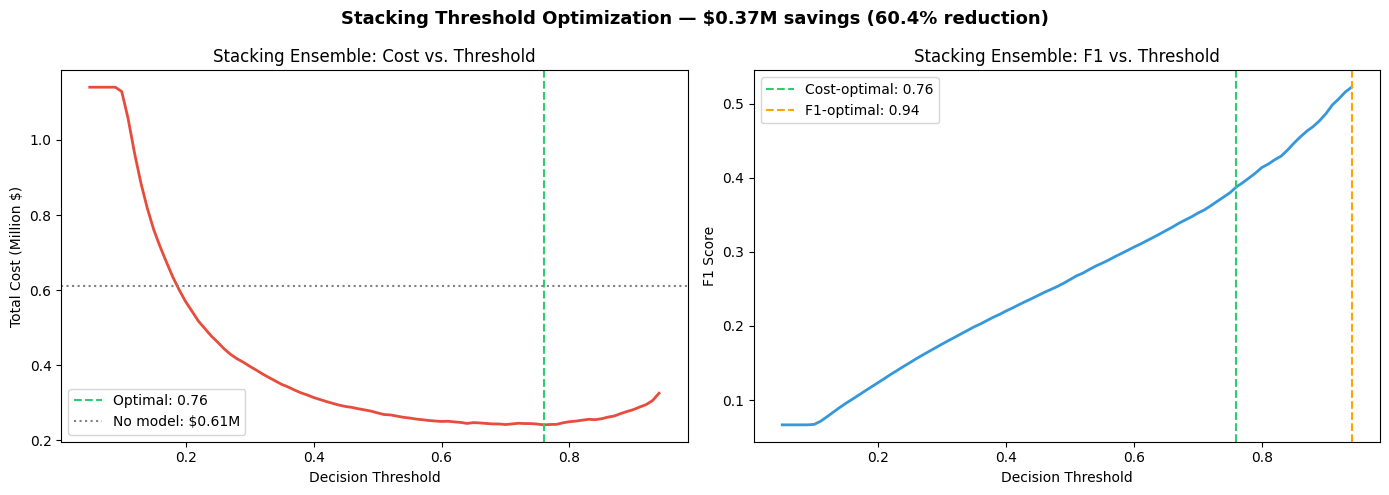

Saved: stacking_threshold_optimization.png
Download this file and add it to reports/ in your repository


In [ ]:
# Plot: Cost vs Threshold (Stacking)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds, total_costs / 1e6, color='#e74c3c', linewidth=2)
axes[0].axvline(optimal_thresh, color='#2ecc71', linestyle='--',
                label=f'Optimal: {optimal_thresh:.2f}')
axes[0].axhline(no_model_cost / 1e6, color='gray', linestyle=':',
                label=f'No model: ${no_model_cost/1e6:.2f}M')
axes[0].set_xlabel('Decision Threshold')
axes[0].set_ylabel('Total Cost (Million $)')
axes[0].set_title('Stacking Ensemble: Cost vs. Threshold')
axes[0].legend()

axes[1].plot(thresholds, f1_scores_sweep, color='#3498db', linewidth=2)
axes[1].axvline(optimal_thresh, color='#2ecc71', linestyle='--',
                label=f'Cost-optimal: {optimal_thresh:.2f}')
f1_optimal_idx = np.argmax(f1_scores_sweep)
axes[1].axvline(thresholds[f1_optimal_idx], color='orange', linestyle='--',
                label=f'F1-optimal: {thresholds[f1_optimal_idx]:.2f}')
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('Stacking Ensemble: F1 vs. Threshold')
axes[1].legend()

plt.suptitle(f'Stacking Threshold Optimization — ${savings/1e6:.2f}M savings ({savings_pct:.1f}% reduction)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('stacking_threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: stacking_threshold_optimization.png')
print('Download this file and add it to reports/ in your repository')

In [ ]:
# Save predictions so we don't lose them if the Colab runtime disconnects

joblib.dump(stack_proba, 'stack_proba.pkl')
joblib.dump(y_test, 'y_test_stack.pkl')
joblib.dump(test_amounts, 'test_amounts_stack.pkl')
joblib.dump({
    'optimal_threshold': optimal_thresh,
    'optimal_cost': optimal_cost,
    'no_model_cost': no_model_cost,
    'savings': savings,
    'savings_pct': savings_pct
}, 'stacking_cost_results.pkl')

print('Saved: stack_proba.pkl, y_test_stack.pkl, test_amounts_stack.pkl, stacking_cost_results.pkl')
print('Download these now via the Colab file browser (left sidebar) before the session ends.')

Saved: stack_proba.pkl, y_test_stack.pkl, test_amounts_stack.pkl, stacking_cost_results.pkl
Download these now via the Colab file browser (left sidebar) before the session ends.
